### APM348 Midterm 1 Group

For the midterm, you can use one of these two versions of Euler's method:
- Euler's Method for 1st order ODEs
- Euler's Method for 2nd order ODEs


#### Euler's Method for 1st order ODEs

Below you can find code to run Euler's Method to approximate the solution of
$$ \frac{dy}{dt} = f(t,y) $$
with the **initial condition** $y(t_0) = y_0$.

The method will approximate the solution for the points $t_i = t_0 + i h$ for $i = 0, \ldots, n$ where the following information needs to be defined:
- `t_span`$ = ( t_0, t_n)$
- `h` where $n = \frac{t_n - t_0}{h}$ 
- `y0` = $y_0$
- `f(t,y)`

After running Euler's Method, the approximation will be stored as:
- `t` a list containing all the points $t_i$
- `y` a list containing the approximation of $y(t_i)$

The code will also plot the solution found.


#### Test questions

To answer the questions in the test, you may need to manipulate the variables to obtain the required information. 


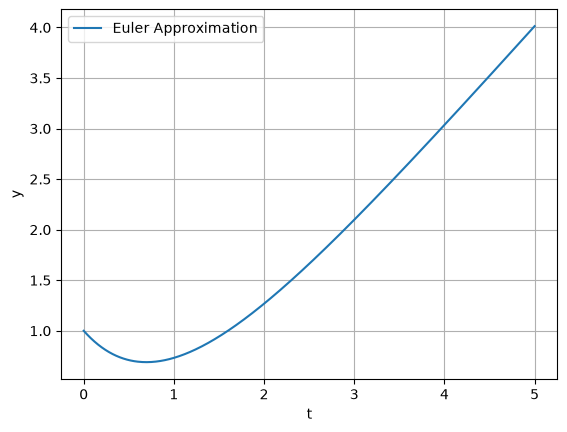

In [146]:
import numpy as np
import matplotlib.pyplot as plt

def euler_method(f, t_span, y0, h):
    """
    Approximates the solution of a first-order ODE using Euler's method.

    Args:
        f: The function defining the ODE, y' = f(t, y).
        t_span: A tuple (t0, tf) representing the start and end times.
        y0: The initial condition, y(t0).
        h: The step size.

    Returns:
        A tuple containing arrays of t and y values.
    """

    t0, tf = t_span
    t = np.arange(t0, tf + h, h)  # Create t values with correct endpoint
    n = len(t)
    y = np.zeros(n)
    y[0] = y0

    for i in range(n - 1):
        y[i+1] = y[i] + h * f(t[i], y[i])

    return t, y

# Example usage: Solve dy/dt = -y + t, y(0) = 1, from t=0 to t=5

def f(t, y):
    return -y+t

    
t_span = (0, 5)
y0 = 1
h = 0.01  # Step size
    
t, y = euler_method(f, t_span, y0, h)


"""Plots the solution obtained from Euler's method."""
plt.plot(t, y, linestyle='-', label='Euler Approximation')
plt.xlabel('t')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()



#### Euler's Method for 2nd order ODEs

Below you can find code to run Euler's Method to approximate the solution of
$$ \frac{d^2y}{dt^2} = f\left(t,y, \frac{dy}{dt}\right) $$
with the **initial conditions** $y(t_0) = y_0$ and $\frac{dy}{dt}(t_0) = y_1$.

The method will approximate the solution for the points $t_i = t_0 + i h$ for $i = 0, \ldots, n$ where the following information needs to be defined:
- `t_span`$ = ( t_0, t_n)$
- `h` where $n = \frac{t_n - t_0}{h}$ 
- `y0` = $y_0$
- `y1` = $y_1$
- `f(t,y,z)` where $z = \frac{dy}{dt}$

After running Euler's Method, the approximation will be stored as:
- `t` a list containing all the points $t_i$
- `y` a list containing the approximation of $y(t_i)$

The code will also plot the solution found.


#### Test questions

To answer the questions in the test, you may need to manipulate the variables to obtain the required information. 


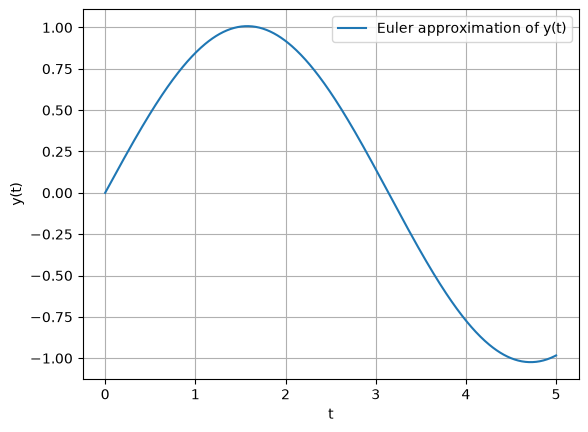

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def euler_method_2nd_order(f, t_span, y0, y1, h):
    """Approximate y for y'' = f(t, y, y') using Euler's method.

    Convert the second-order ODE to the first-order system
        y' = z
        z' = f(t, y, z)

    Args:
        f: Acceleration function, f(t, y, z).
        t_span: Tuple (t0, tf) for the time interval.
        y0: Initial value y(t0).
        y1: Initial derivative y'(t0).
        h: Step size.

    Returns:
        Arrays t and y containing the time points and approximation of y(t).
    """
    t0, tf = t_span
    t = np.arange(t0, tf + h, h)
    n = len(t)
    y = np.zeros(n)
    z = np.zeros(n)
    y[0] = y0
    z[0] = y1

    for i in range(n - 1):
        y[i + 1] = y[i] + h * z[i]
        z[i + 1] = z[i] + h * f(t[i], y[i], z[i])

    return t, y


# Example: solve y'' = -y with y(0) = 0 and y'(0) = 1, from t=0 to t=5.
def f(t, y, z):
    return -y


t_span = (0, 5)
y0 = 0
y1 = 1
h = 0.01

t, y = euler_method_2nd_order(f, t_span, y0, y1, h)

plt.plot(t, y, linestyle='-', label="Euler approximation of y(t)")
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
plt.legend()
plt.show()
